# Trực quan hóa quá trình tấn công Adversarial

### FGSM & I-FGSM — SimpleCNN trên MNIST và CIFAR-10



Notebook minh họa **từng bước** cách nhiễu đối kháng được tạo ra,

thay vì chỉ xem biểu đồ kết quả tổng hợp.

In [1]:
import sys, os
sys.path.insert(0, '.')

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from torchvision import datasets, transforms
from IPython.display import display

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

from models import SimpleCNN
from attacks.fgsm import fgsm_attack
from attacks.ifgsm import IFGSMAttack

DEVICE = torch.device('cpu')
NL = chr(10)   # dùng trong f-string thay cho \n
print("\u2713 Imports OK")

✓ Imports OK


## 1. Load mô hình đã huấn luyện

In [2]:
mnist_model = SimpleCNN(in_channels=1, num_classes=10, input_size=28).to(DEVICE)
ck = torch.load('results/checkpoints/mnist_best.pth', map_location=DEVICE)
mnist_model.load_state_dict(ck['model_state'])
mnist_model.eval()

cifar_model = SimpleCNN(in_channels=3, num_classes=10, input_size=32).to(DEVICE)
ck = torch.load('results/checkpoints/cifar10_best.pth', map_location=DEVICE)
cifar_model.load_state_dict(ck['model_state'])
cifar_model.eval()

MNIST_CLS = [str(i) for i in range(10)]
CIFAR_CLS = ['airplane','automobile','bird','cat','deer',
              'dog','frog','horse','ship','truck']

print('\u2713 MNIST   best_val_acc:', torch.load('results/checkpoints/mnist_best.pth',
       map_location='cpu')['best_val_acc'])
print('\u2713 CIFAR-10 best_val_acc:', ck['best_val_acc'])

✓ MNIST   best_val_acc: 98.98333333333333
✓ CIFAR-10 best_val_acc: 74.36


## 2. Lấy ảnh mẫu từ tập test

In [3]:
mnist_test = datasets.MNIST('data', train=False, download=True,
                             transform=transforms.ToTensor())
cifar_test = datasets.CIFAR10('data', train=False, download=True,
                               transform=transforms.ToTensor())

def get_correct_samples(model, dataset, n=5):
    '''Lấy n ảnh mô hình phân loại đúng.'''
    imgs, labels = [], []
    for img, lbl in dataset:
        img_t = img.unsqueeze(0)
        with torch.no_grad():
            pred = model(img_t).argmax(1).item()
        if pred == lbl:
            imgs.append(img_t)
            labels.append(lbl)
        if len(imgs) >= n:
            break
    return torch.cat(imgs), torch.tensor(labels)

mnist_imgs,  mnist_labels  = get_correct_samples(mnist_model,  mnist_test,  n=5)
cifar_imgs,  cifar_labels  = get_correct_samples(cifar_model,  cifar_test,  n=5)

print('MNIST  samples:', [MNIST_CLS[l] for l in mnist_labels.tolist()])
print('CIFAR samples: ', [CIFAR_CLS[l] for l in cifar_labels.tolist()])

MNIST  samples: ['7', '2', '1', '0', '4']
CIFAR samples:  ['cat', 'ship', 'ship', 'airplane', 'cat']


/home/wotttoo/miniconda3/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## 3. Hàm tiện ích

In [4]:
def to_img(t):
    t = t.squeeze(0).clamp(0,1)
    return t.permute(1,2,0).numpy() if t.shape[0]==3 else t.squeeze().numpy()

def get_probs(model, img_t):
    with torch.no_grad():
        return torch.softmax(model(img_t), dim=1).squeeze().numpy()

def confidence_bar(ax, probs, class_names, true_idx, title='', fs=9.5):
    pred_idx = probs.argmax()
    colors = []
    for i in range(len(class_names)):
        if i == pred_idx and i == true_idx:  colors.append('#2ca02c')
        elif i == pred_idx:                   colors.append('#d62728')
        elif i == true_idx:                   colors.append('#aec7e8')
        else:                                 colors.append('#cccccc')
    ax.barh(range(len(class_names)), probs*100, color=colors,
            edgecolor='white', height=0.72)
    ax.set_yticks(range(len(class_names)))
    ax.set_yticklabels(class_names, fontsize=fs)
    ax.set_xlim(0, 110)
    ax.set_title(title, fontsize=fs+1, fontweight='bold')
    ax.invert_yaxis()
    for i, p in enumerate(probs):
        if p > 0.03:
            ax.text(p*100+1.5, i, f'{p*100:.1f}%', va='center', fontsize=fs-1)
    ax.set_xticks([])
    ax.spines[['left','bottom']].set_visible(False)

print('\u2713 Helpers ready')

✓ Helpers ready


## 4. FGSM — Trực quan hóa từng ảnh



**Công thức:** $x_{adv} = x + \varepsilon \cdot \text{sign}(\nabla_x J(\theta, x, y))$



- **Ảnh gốc** $x$ — mô hình phân loại đúng

- **Nhiễu** $\varepsilon \cdot \text{sign}(\nabla_x J)$ — khuếch đại ×10 để nhìn thấy


- **Ảnh đối kháng** $x_{adv}$ — mô hình phân loại sai

In [5]:
def visualize_fgsm(model, img_t, label, class_names,
                   epsilon=0.2, cmap=None, suptitle=''):
    model.eval()
    lbl_t = torch.tensor([label])
    adv_t = fgsm_attack(model, img_t, lbl_t, epsilon=epsilon)
    noise  = adv_t - img_t

    p_orig = get_probs(model, img_t)
    p_adv  = get_probs(model, adv_t)
    pred_adv = p_adv.argmax()

    noise_vis = to_img((noise * 10 + 0.5).clamp(0,1))

    fig = plt.figure(figsize=(15, 5.8))
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, fontweight='bold', y=1.02)

    gs = gridspec.GridSpec(2, 5, figure=fig,
                           height_ratios=[1.1, 1],
                           width_ratios=[1, 0.18, 1, 0.18, 1],
                           hspace=0.55, wspace=0.1)
    kw = dict(cmap=cmap, vmin=0, vmax=1)

    # Ảnh gốc
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(to_img(img_t), **kw)
    ax0.set_title(
        'Anh goc' + NL + f'\u2713  "{class_names[label]}"  ({p_orig[label]*100:.1f}%)',
        color='#2ca02c', fontsize=11, fontweight='bold')
    ax0.axis('off')

    # Dấu +
    ax_p = fig.add_subplot(gs[0, 1])
    ax_p.text(0.5, 0.62, '+', ha='center', va='center', fontsize=32, color='#555')
    ax_p.text(0.5, 0.25, f'\u03b5={epsilon}' + NL + 'x sign(\u2207J)',
              ha='center', va='center', fontsize=8.5, color='#666')
    ax_p.axis('off')

    # Nhiễu
    ax1 = fig.add_subplot(gs[0, 2])
    ax1.imshow(noise_vis, cmap=cmap, vmin=0, vmax=1)
    ax1.set_title('Nhieu doi khang' + NL + '(khuech dai x10)',
                  color='#555', fontsize=11)
    ax1.axis('off')

    # Dấu =
    ax_e = fig.add_subplot(gs[0, 3])
    ax_e.text(0.5, 0.62, '=', ha='center', va='center', fontsize=32, color='#555')
    ax_e.axis('off')

    # Ảnh đối kháng
    ax2 = fig.add_subplot(gs[0, 4])
    ax2.imshow(to_img(adv_t), **kw)
    ok  = pred_adv == label
    sym = '\u2713' if ok else '\u2717'
    col = '#2ca02c' if ok else '#d62728'
    ax2.set_title(
        'Anh doi khang' + NL + f'{sym}  "{class_names[pred_adv]}"  ({p_adv[pred_adv]*100:.1f}%)',
        color=col, fontsize=11, fontweight='bold')
    ax2.axis('off')

    # Confidence bars
    ax3 = fig.add_subplot(gs[1, :2])
    confidence_bar(ax3, p_orig, class_names, label, title='Confidence TRUOC tan cong')
    ax4 = fig.add_subplot(gs[1, 3:])
    confidence_bar(ax4, p_adv,  class_names, label, title='Confidence SAU tan cong')

    # Legend
    patches = [mpatches.Patch(color='#2ca02c', label='Du doan dung'),
               mpatches.Patch(color='#d62728', label='Du doan sai'),
               mpatches.Patch(color='#aec7e8', label='Nhan that')]
    fig.legend(handles=patches, loc='lower center', ncol=3,
               fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.06))
    plt.tight_layout()
    plt.show()

print('\u2713 visualize_fgsm() ready')

✓ visualize_fgsm() ready


### 4.1 FGSM trên MNIST

/tmp/ipykernel_18860/2327427270.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


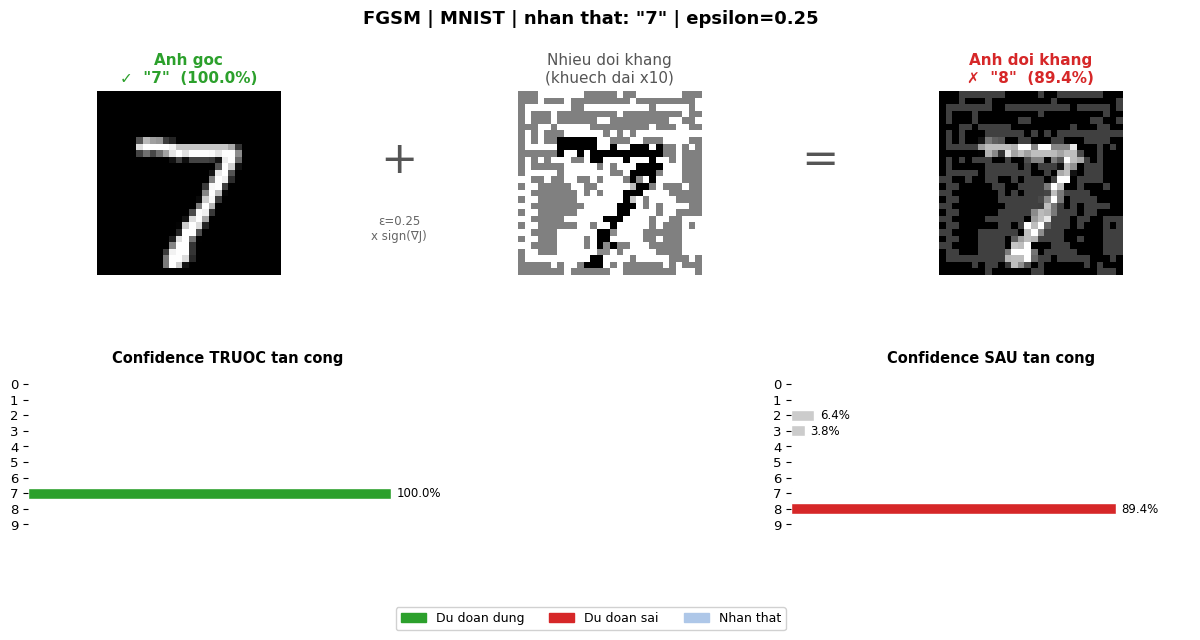

/tmp/ipykernel_18860/2327427270.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


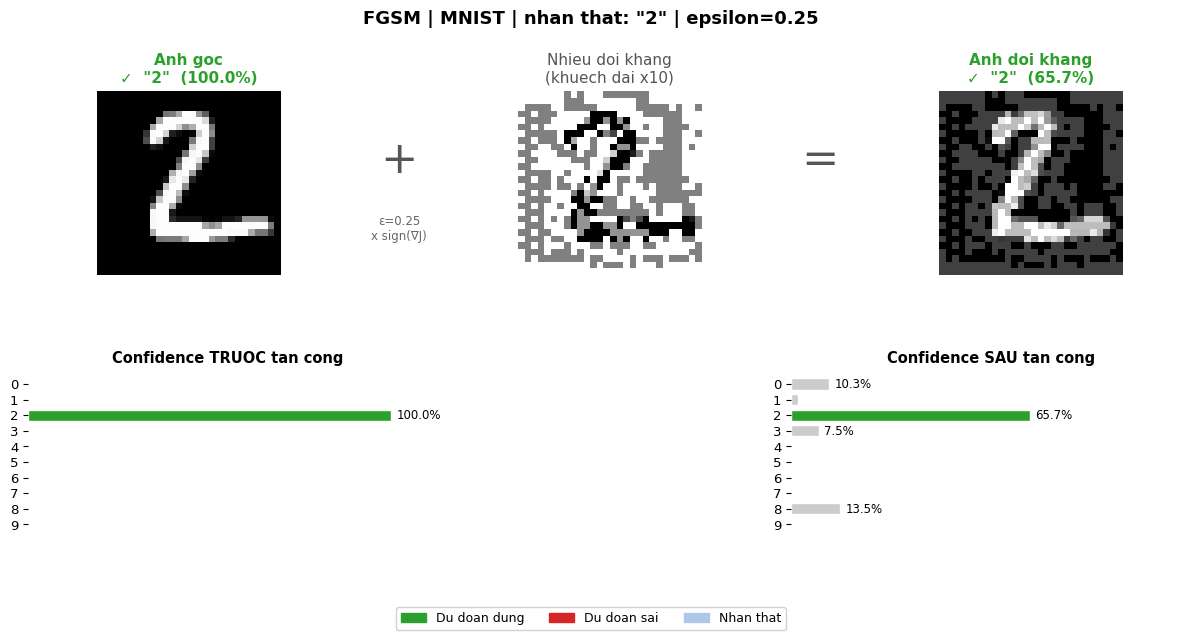

/tmp/ipykernel_18860/2327427270.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


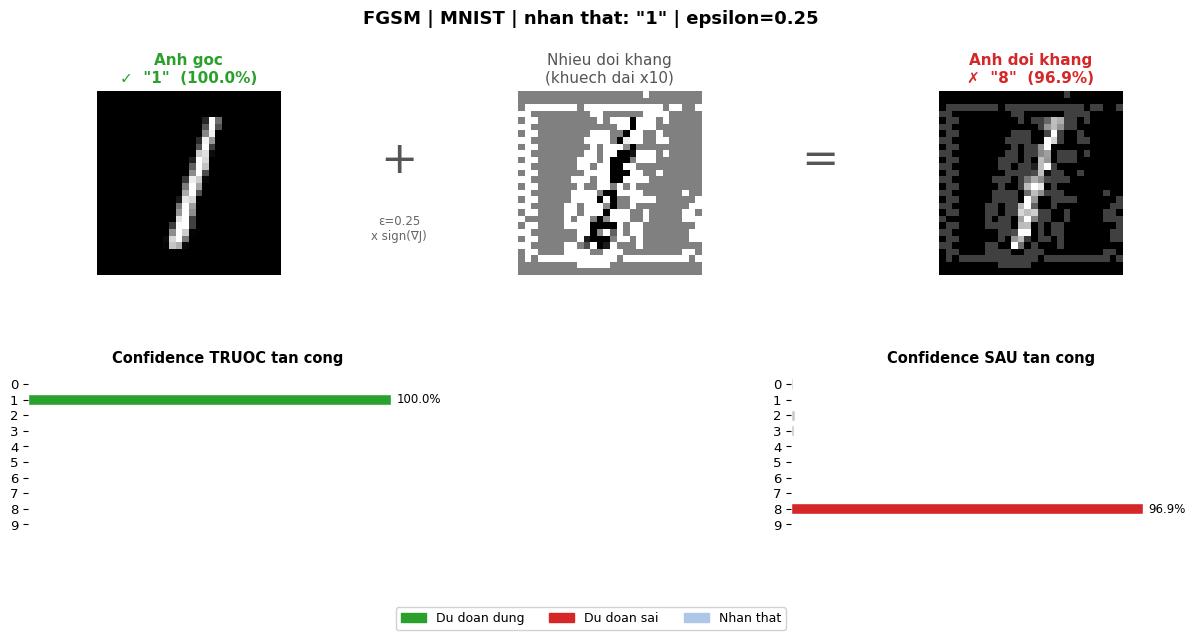

In [6]:
for i in range(3):
    visualize_fgsm(
        mnist_model, mnist_imgs[i].unsqueeze(0), mnist_labels[i].item(),
        MNIST_CLS, epsilon=0.25, cmap='gray',
        suptitle=f'FGSM | MNIST | nhan that: "{MNIST_CLS[mnist_labels[i]]}" | epsilon=0.25'
    )

### 4.2 FGSM trên CIFAR-10

/tmp/ipykernel_18860/2327427270.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


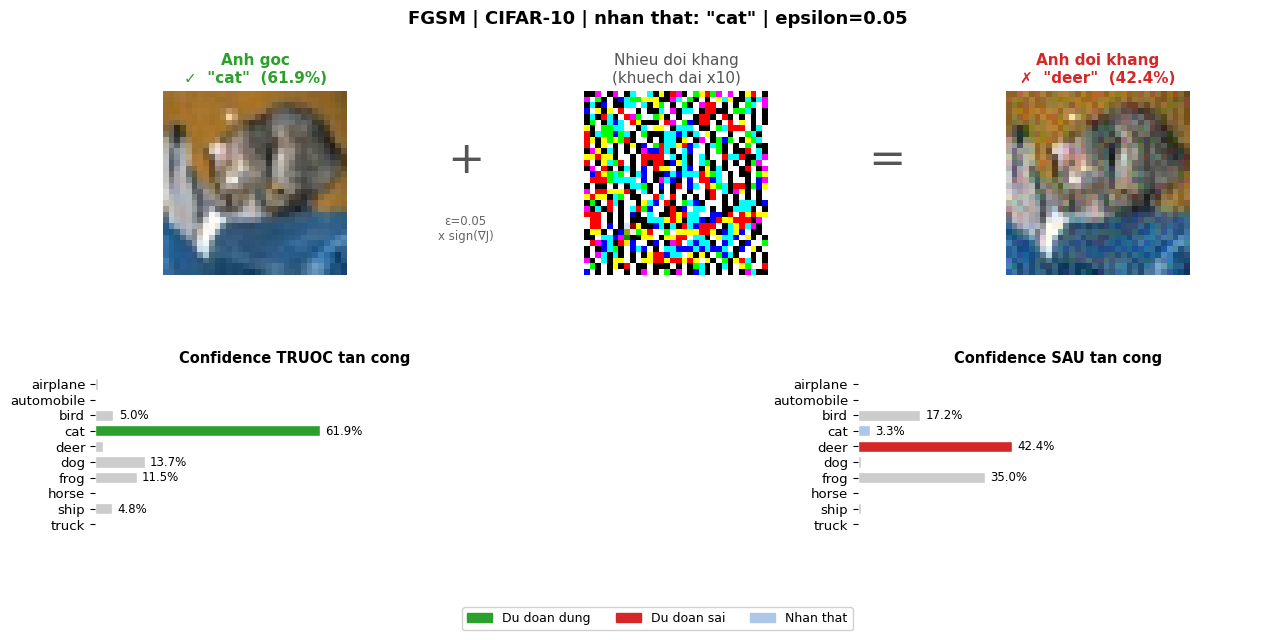

/tmp/ipykernel_18860/2327427270.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


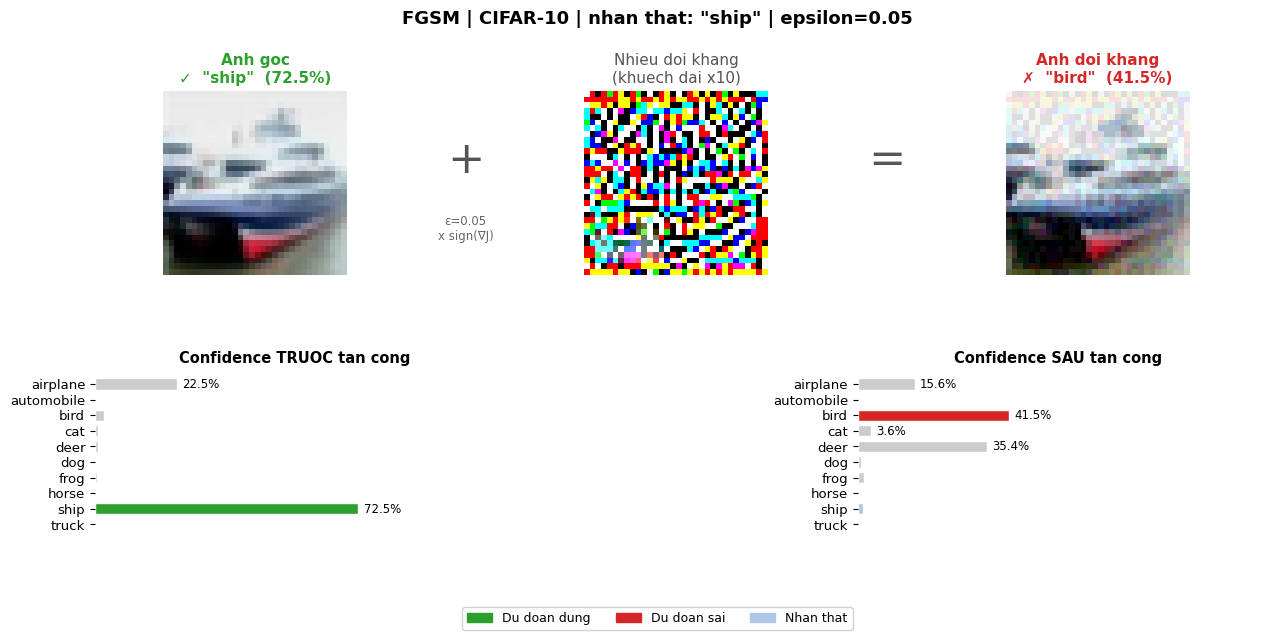

/tmp/ipykernel_18860/2327427270.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


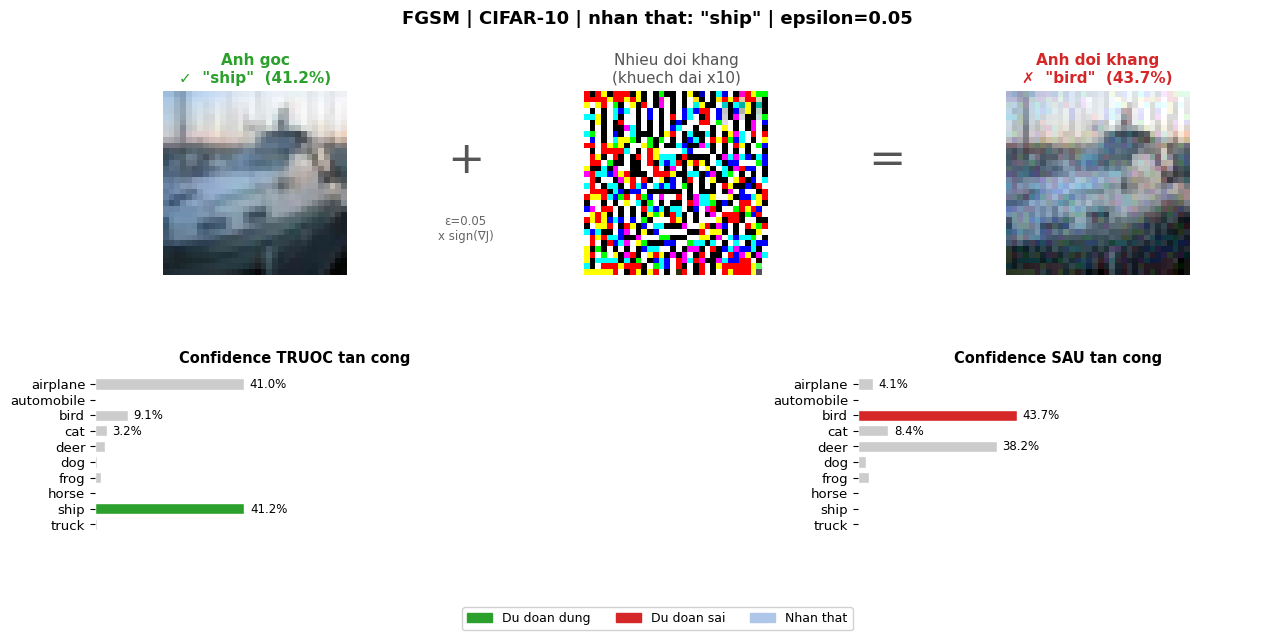

In [7]:
for i in range(3):
    visualize_fgsm(
        cifar_model, cifar_imgs[i].unsqueeze(0), cifar_labels[i].item(),
        CIFAR_CLS, epsilon=0.05, cmap=None,
        suptitle=f'FGSM | CIFAR-10 | nhan that: "{CIFAR_CLS[cifar_labels[i]]}" | epsilon=0.05'
    )

### 4.3 Ảnh hưởng của ε — cùng ảnh, nhiều giá trị ε

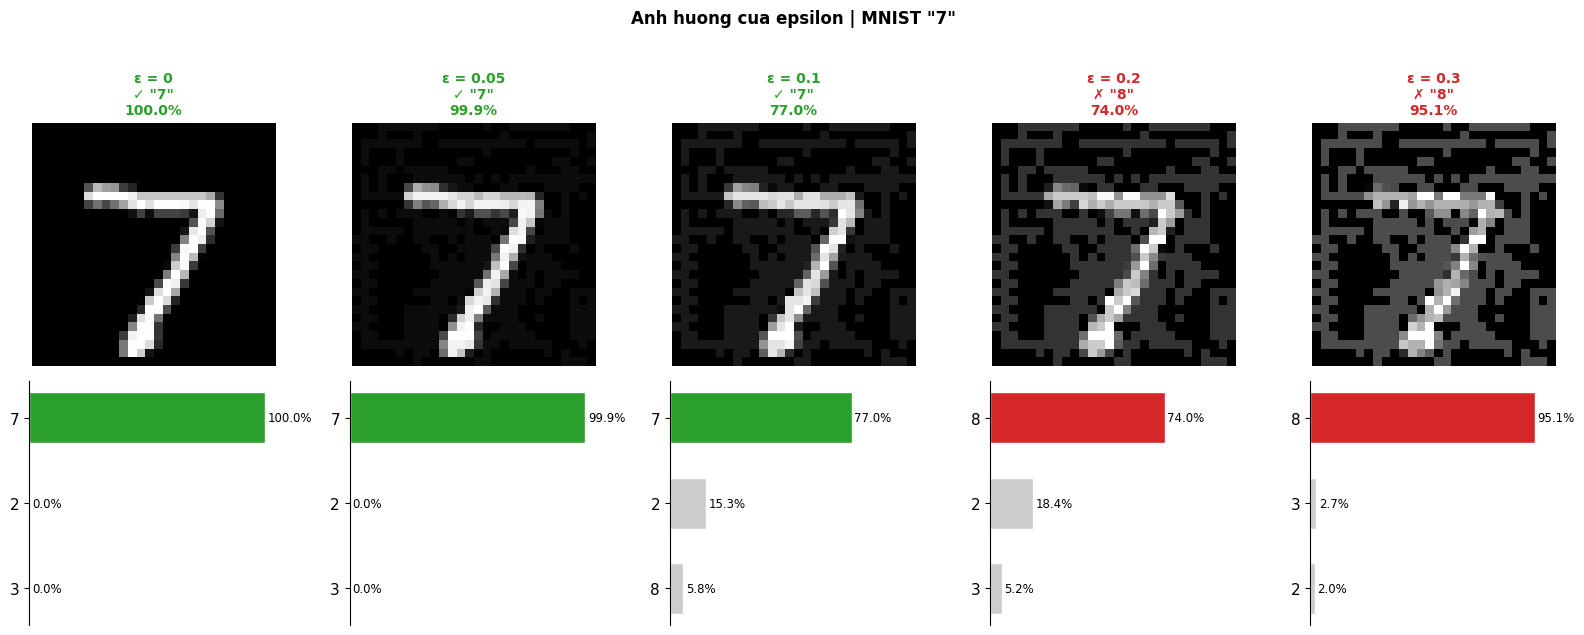

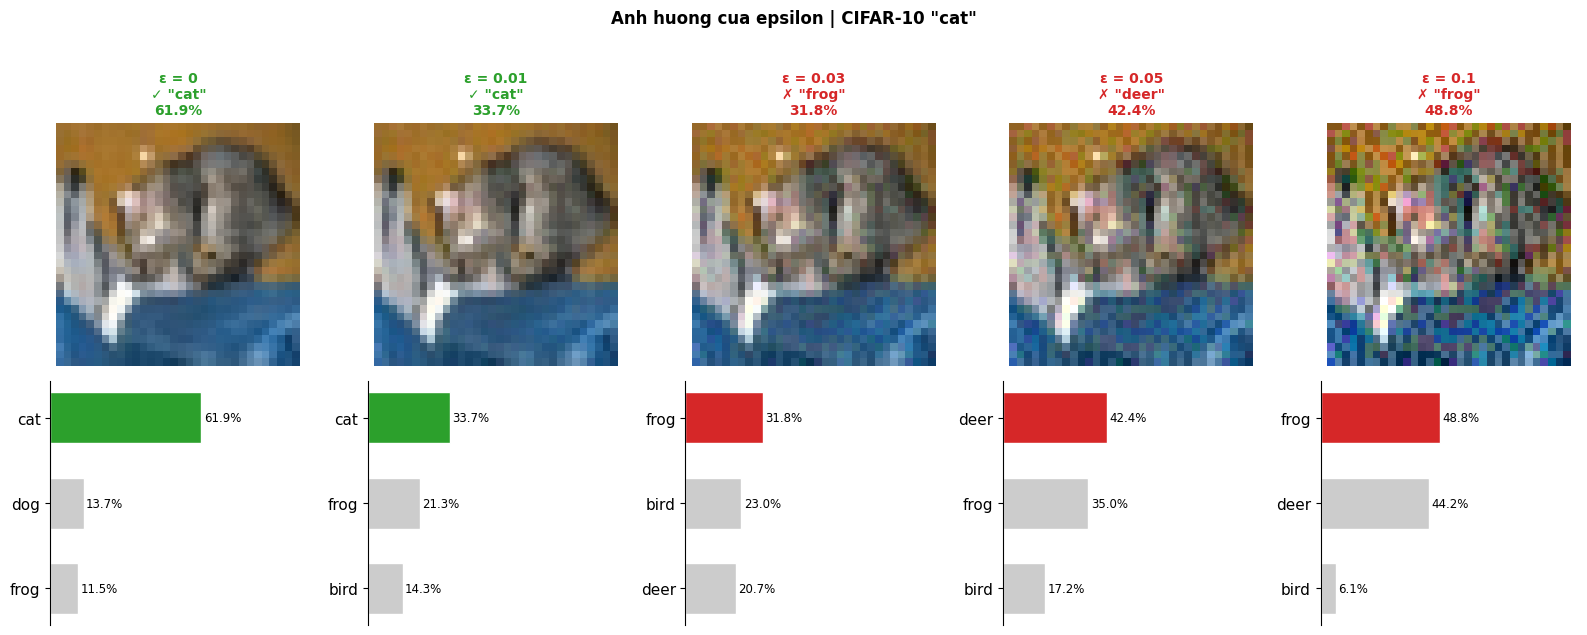

In [8]:
def viz_epsilon_sweep(model, img_t, label, class_names,
                      epsilons, cmap=None, suptitle=''):
    n = len(epsilons)
    fig, axes = plt.subplots(2, n, figsize=(3.2*n, 6.2))
    if suptitle:
        fig.suptitle(suptitle, fontsize=12, fontweight='bold', y=1.02)
    model.eval()
    lbl_t = torch.tensor([label])
    for col, eps in enumerate(epsilons):
        adv = fgsm_attack(model, img_t, lbl_t, epsilon=eps) if eps > 0 else img_t
        p   = get_probs(model, adv)
        pred = p.argmax()
        ok   = pred == label
        col_c = '#2ca02c' if ok else '#d62728'
        sym   = '\u2713' if ok else '\u2717'
        axes[0,col].imshow(to_img(adv), cmap=cmap, vmin=0, vmax=1)
        axes[0,col].axis('off')
        axes[0,col].set_title(
            f'\u03b5 = {eps}' + NL + f'{sym} "{class_names[pred]}"' + NL + f'{p[pred]*100:.1f}%',
            fontsize=10, color=col_c, fontweight='bold')
        top3 = np.argsort(p)[::-1][:3]
        cb = ['#2ca02c' if i==label else '#d62728' if i==pred else '#ccc' for i in top3]
        axes[1,col].barh([class_names[i] for i in top3[::-1]],
                         [p[i]*100 for i in top3[::-1]],
                         color=cb[::-1], edgecolor='white', height=0.6)
        axes[1,col].set_xlim(0, 105)
        axes[1,col].set_xticks([])
        axes[1,col].spines[['top','right','bottom']].set_visible(False)
        for j, i in enumerate(top3[::-1]):
            axes[1,col].text(p[i]*100+1, j, f'{p[i]*100:.1f}%', va='center', fontsize=8.5)
    plt.tight_layout(); plt.show()

viz_epsilon_sweep(
    mnist_model, mnist_imgs[0].unsqueeze(0), mnist_labels[0].item(),
    MNIST_CLS, epsilons=[0, 0.05, 0.10, 0.20, 0.30], cmap='gray',
    suptitle=f'Anh huong cua epsilon | MNIST "{MNIST_CLS[mnist_labels[0]]}"'
)
viz_epsilon_sweep(
    cifar_model, cifar_imgs[0].unsqueeze(0), cifar_labels[0].item(),
    CIFAR_CLS, epsilons=[0, 0.01, 0.03, 0.05, 0.10],
    suptitle=f'Anh huong cua epsilon | CIFAR-10 "{CIFAR_CLS[cifar_labels[0]]}"'
)

## 5. I-FGSM — Từng bước lặp



**Công thức:** $x_0 = x,\quad x_{t+1} = \text{Clip}_{x,\varepsilon}\left[x_t + \alpha \cdot \text{sign}\bigl(\nabla_x J(\theta, x_t, y)\bigr)\right]$



Với $\alpha = \varepsilon / T$ (bước nhỏ mỗi iteration).

In [9]:
def ifgsm_capture(model, img_t, label, epsilon=0.2,
                  num_steps=40, capture_at=None):
    if capture_at is None:
        capture_at = [0, 1, 2, 5, 10, 20, num_steps]
    model.eval()
    alpha = epsilon / num_steps
    lbl_t = torch.tensor([label])
    adv   = img_t.clone()
    captured, loss_hist, conf_hist = {}, [], []
    for step in range(num_steps + 1):
        if step in capture_at:
            with torch.no_grad():
                p = torch.softmax(model(adv), dim=1).squeeze().numpy()
            captured[step] = (adv.clone().detach(), p.copy())
        if step == num_steps:
            break
        adv_r = adv.detach().requires_grad_(True)
        out   = model(adv_r)
        loss  = F.cross_entropy(out, lbl_t)
        model.zero_grad()
        loss.backward()
        with torch.no_grad():
            p_now = torch.softmax(out, dim=1).squeeze().numpy()
            loss_hist.append(loss.item())
            conf_hist.append(float(p_now[label]))
        adv = adv.detach() + alpha * adv_r.grad.sign()
        adv = img_t + (adv - img_t).clamp(-epsilon, epsilon)
        adv = adv.clamp(0, 1)
    return captured, loss_hist, conf_hist

print('\u2713 ifgsm_capture() ready')

✓ ifgsm_capture() ready


In [10]:
def visualize_ifgsm(model, img_t, label, class_names,
                    epsilon=0.2, num_steps=40, cmap=None, suptitle=''):
    CAPTURE = [0, 1, 2, 5, 10, 20, num_steps]
    captured, loss_hist, conf_hist = ifgsm_capture(
        model, img_t, label, epsilon=epsilon,
        num_steps=num_steps, capture_at=CAPTURE)

    n_fr = len(CAPTURE)
    fig = plt.figure(figsize=(3.0*n_fr, 7.5))
    if suptitle:
        fig.suptitle(suptitle, fontsize=12, fontweight='bold', y=1.01)
    gs = gridspec.GridSpec(2, n_fr, figure=fig,
                           height_ratios=[1.4, 1], hspace=0.6, wspace=0.22)

    for col, step in enumerate(CAPTURE):
        adv_t, probs = captured[step]
        pred = probs.argmax()
        ok   = pred == label
        col_c = '#2ca02c' if ok else '#d62728'
        sym   = '\u2713' if ok else '\u2717'
        ax = fig.add_subplot(gs[0, col])
        ax.imshow(to_img(adv_t), cmap=cmap, vmin=0, vmax=1)
        ax.axis('off')
        ax.set_title(
            f'Buoc {step}' + NL + f'{sym} "{class_names[pred]}"' + NL + f'{probs[pred]*100:.1f}%',
            fontsize=9, color=col_c, fontweight='bold')
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_color(col_c); sp.set_linewidth(2.5)

    steps_r = range(1, len(loss_hist)+1)
    ax_l = fig.add_subplot(gs[1, :n_fr//2])
    ax_l.plot(steps_r, loss_hist, color='#d62728', lw=2)
    ax_l.fill_between(steps_r, loss_hist, alpha=0.15, color='#d62728')
    ax_l.set_xlabel('Buoc lap', fontsize=10)
    ax_l.set_ylabel('Cross-entropy Loss', fontsize=10)
    ax_l.set_title('Loss tang dan theo buoc lap', fontsize=11, fontweight='bold')
    ax_l.grid(axis='y', alpha=0.3)
    for s in CAPTURE[1:]:
        if s <= len(loss_hist):
            ax_l.axvline(s, color='#888', lw=0.8, ls='--', alpha=0.6)

    ax_c = fig.add_subplot(gs[1, n_fr//2:])
    ax_c.plot(steps_r, [c*100 for c in conf_hist], color='#2ca02c', lw=2)
    ax_c.fill_between(steps_r, [c*100 for c in conf_hist], alpha=0.15, color='#2ca02c')
    ax_c.axhline(50, color='#aaa', lw=0.8, ls='--')
    ax_c.set_xlabel('Buoc lap', fontsize=10)
    ax_c.set_ylabel('Confidence nhan that (%)', fontsize=10)
    ax_c.set_title(f'Confidence "{class_names[label]}" giam dan',
                   fontsize=11, fontweight='bold')
    ax_c.set_ylim(0, 102)
    ax_c.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

print('\u2713 visualize_ifgsm() ready')

✓ visualize_ifgsm() ready


### 5.1 I-FGSM trên MNIST

/tmp/ipykernel_18860/260464454.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


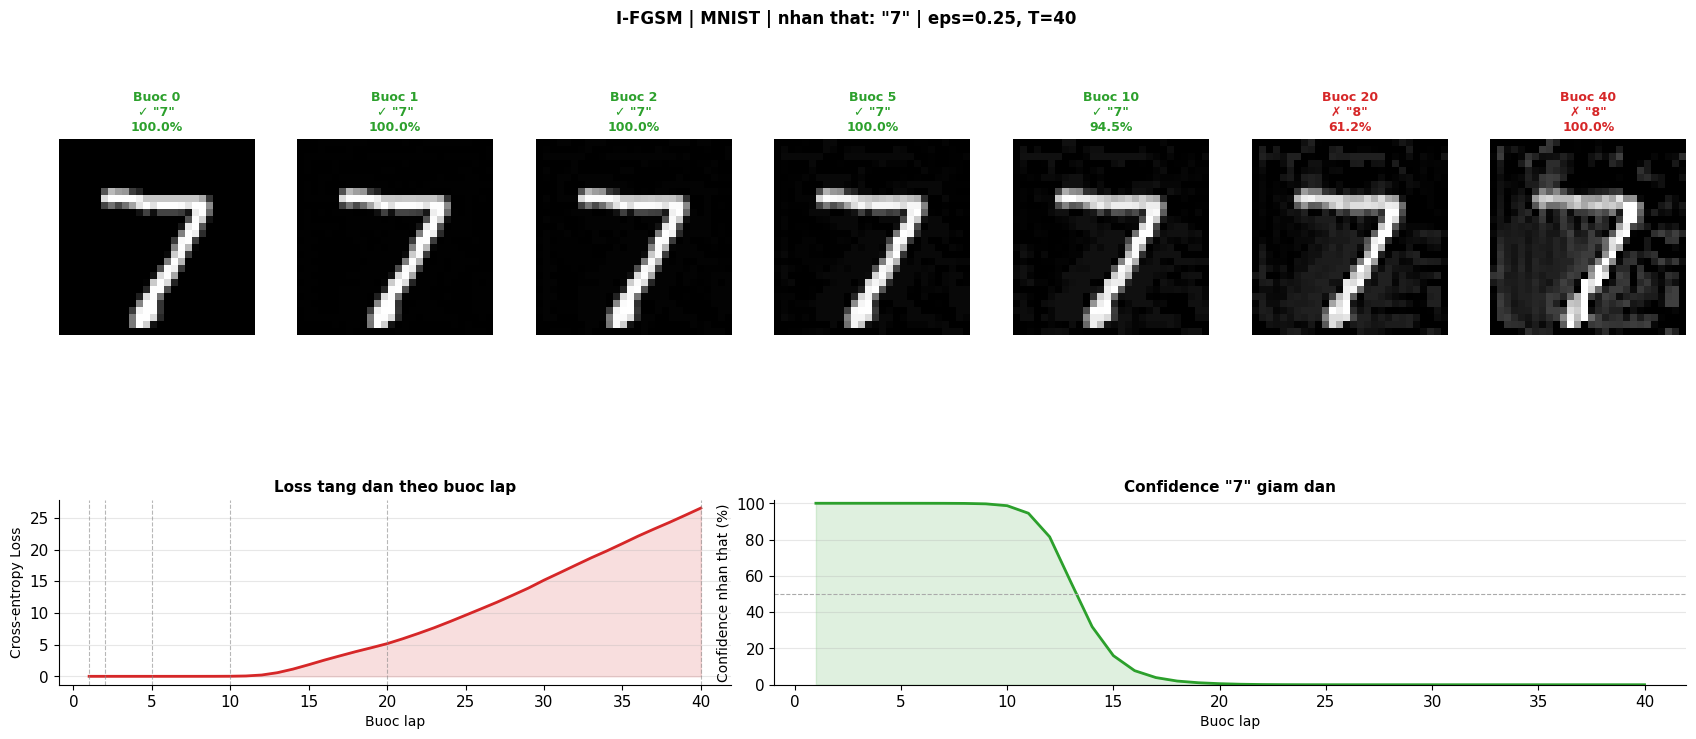

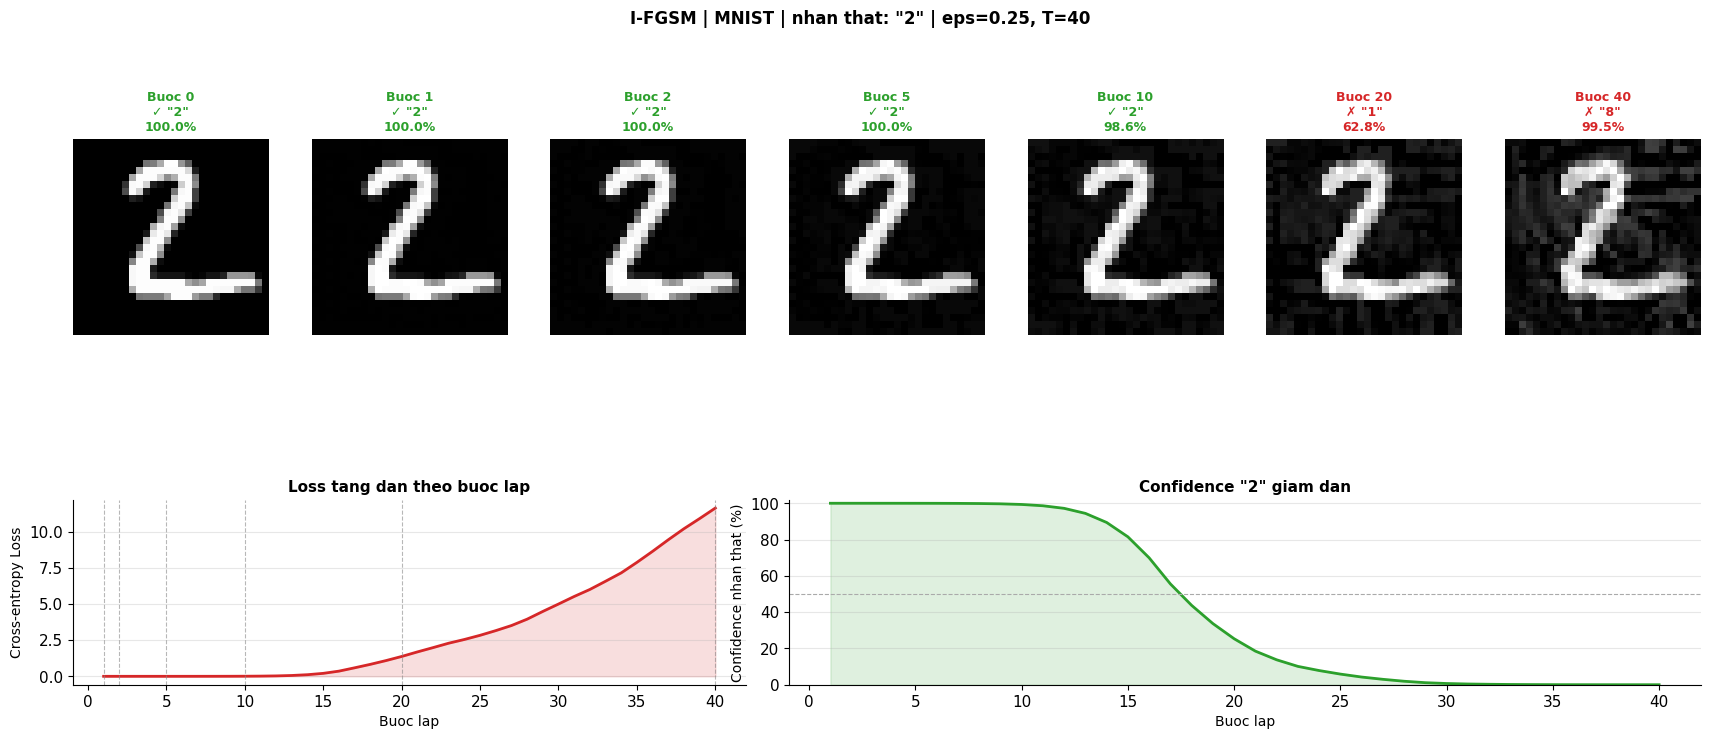

In [11]:
for i in range(2):
    visualize_ifgsm(
        mnist_model, mnist_imgs[i].unsqueeze(0), mnist_labels[i].item(),
        MNIST_CLS, epsilon=0.25, num_steps=40, cmap='gray',
        suptitle=f'I-FGSM | MNIST | nhan that: "{MNIST_CLS[mnist_labels[i]]}" | eps=0.25, T=40'
    )

### 5.2 I-FGSM trên CIFAR-10

/tmp/ipykernel_18860/260464454.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


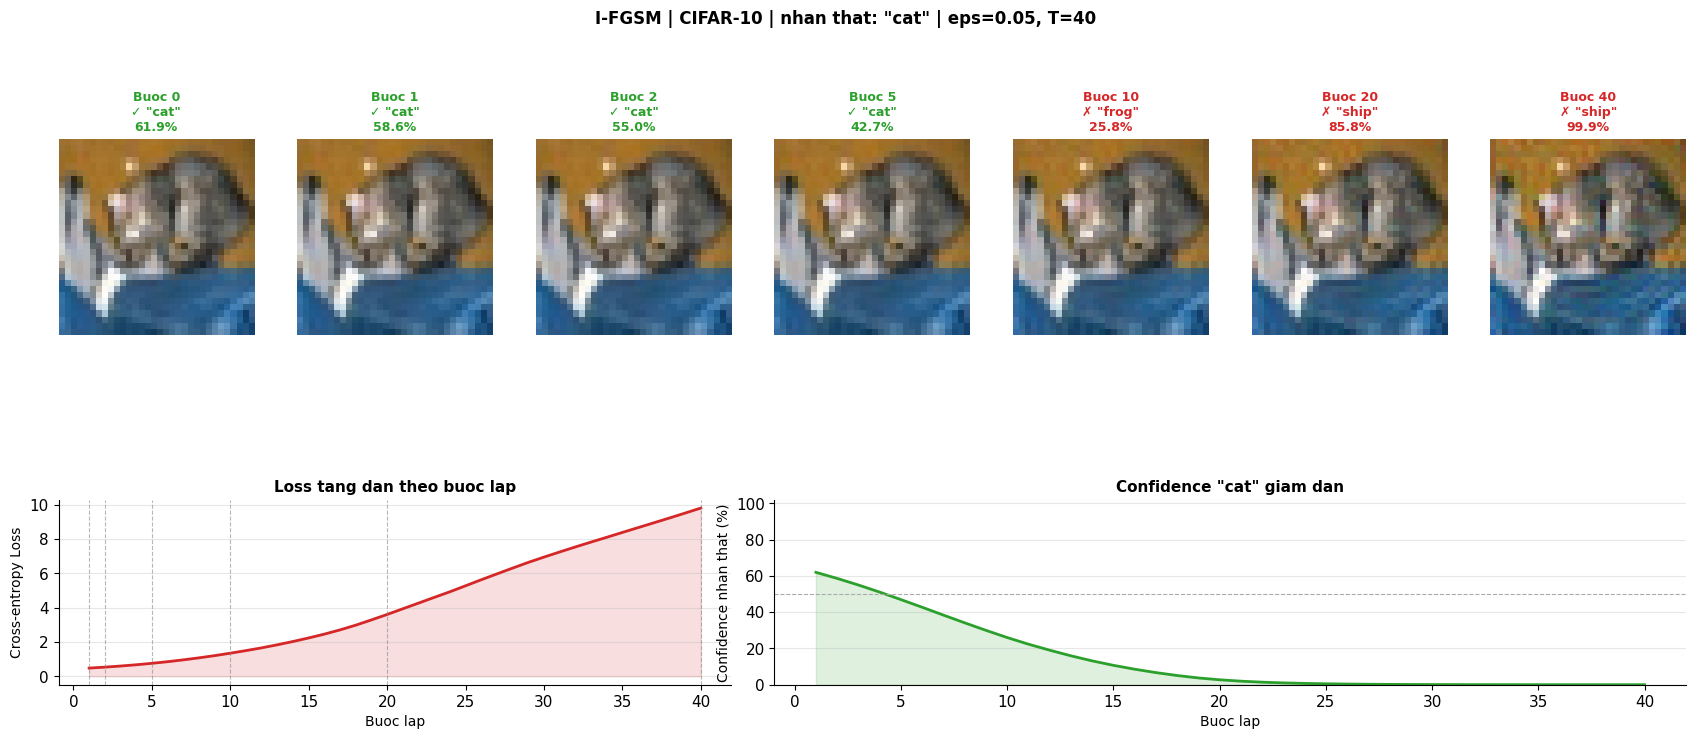

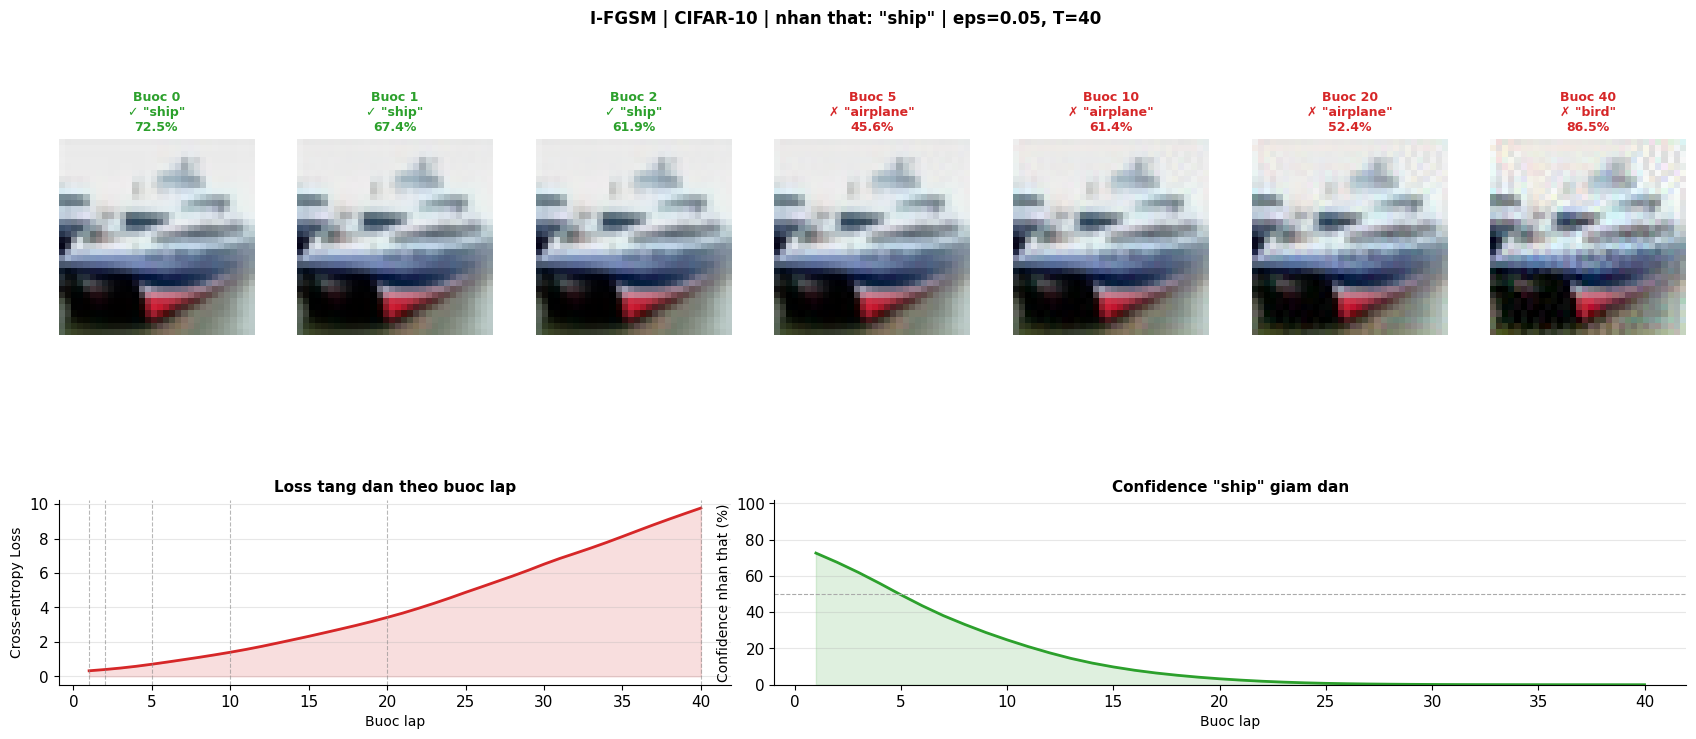

In [12]:
for i in range(2):
    visualize_ifgsm(
        cifar_model, cifar_imgs[i].unsqueeze(0), cifar_labels[i].item(),
        CIFAR_CLS, epsilon=0.05, num_steps=40, cmap=None,
        suptitle=f'I-FGSM | CIFAR-10 | nhan that: "{CIFAR_CLS[cifar_labels[i]]}" | eps=0.05, T=40'
    )

## 6. So sánh FGSM vs I-FGSM — cùng ε



I-FGSM mạnh hơn vì lặp nhiều bước nhỏ, khai thác gradient tốt hơn.

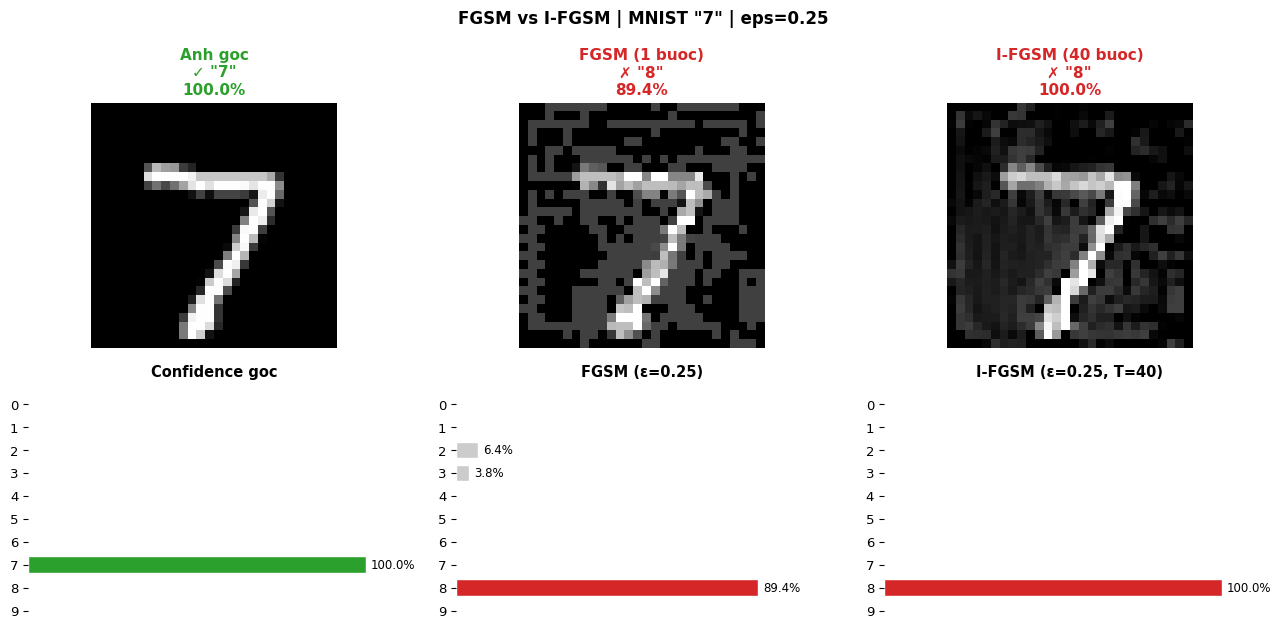

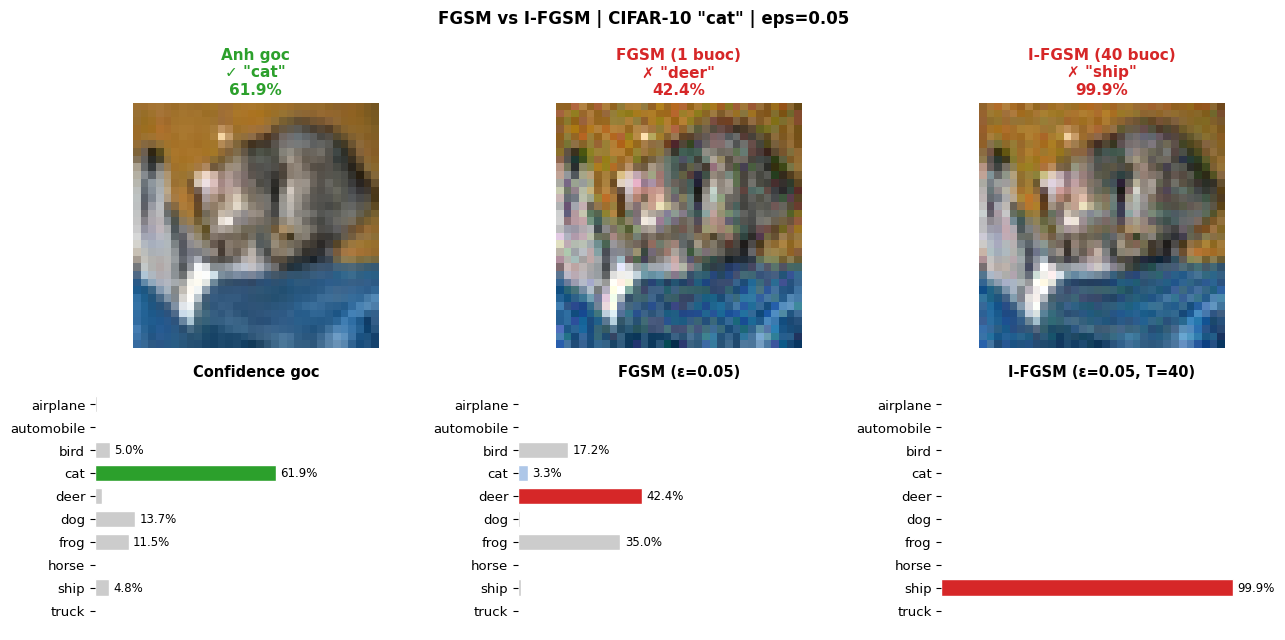

In [13]:
def compare_attacks(model, img_t, label, class_names,
                    epsilon=0.2, num_steps=40, cmap=None, suptitle=''):
    model.eval()
    lbl_t = torch.tensor([label])
    p_orig    = get_probs(model, img_t)
    adv_fgsm  = fgsm_attack(model, img_t, lbl_t, epsilon=epsilon)
    p_fgsm    = get_probs(model, adv_fgsm)
    attacker  = IFGSMAttack(model, epsilon=epsilon, num_steps=num_steps)
    adv_ifgsm = attacker(img_t, lbl_t)
    p_ifgsm   = get_probs(model, adv_ifgsm)
    pred_f, pred_i = p_fgsm.argmax(), p_ifgsm.argmax()

    fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
    if suptitle:
        fig.suptitle(suptitle, fontsize=12, fontweight='bold')
    kw = dict(cmap=cmap, vmin=0, vmax=1)

    # Cột 0: Ảnh gốc
    axes[0,0].imshow(to_img(img_t), **kw); axes[0,0].axis('off')
    axes[0,0].set_title('Anh goc' + NL + f'\u2713 "{class_names[label]}"' + NL + f'{p_orig[label]*100:.1f}%',
                        color='#2ca02c', fontsize=11, fontweight='bold')
    confidence_bar(axes[1,0], p_orig, class_names, label, title='Confidence goc')

    # Cột 1: FGSM
    ok1 = pred_f == label
    sym1 = '\u2713' if ok1 else '\u2717'
    axes[0,1].imshow(to_img(adv_fgsm), **kw); axes[0,1].axis('off')
    axes[0,1].set_title(
        f'FGSM (1 buoc)' + NL + f'{sym1} "{class_names[pred_f]}"' + NL + f'{p_fgsm[pred_f]*100:.1f}%',
        color='#2ca02c' if ok1 else '#d62728', fontsize=11, fontweight='bold')
    confidence_bar(axes[1,1], p_fgsm, class_names, label,
                   title=f'FGSM (\u03b5={epsilon})')

    # Cột 2: I-FGSM
    ok2 = pred_i == label
    sym2 = '\u2713' if ok2 else '\u2717'
    axes[0,2].imshow(to_img(adv_ifgsm), **kw); axes[0,2].axis('off')
    axes[0,2].set_title(
        f'I-FGSM ({num_steps} buoc)' + NL + f'{sym2} "{class_names[pred_i]}"' + NL + f'{p_ifgsm[pred_i]*100:.1f}%',
        color='#2ca02c' if ok2 else '#d62728', fontsize=11, fontweight='bold')
    confidence_bar(axes[1,2], p_ifgsm, class_names, label,
                   title=f'I-FGSM (\u03b5={epsilon}, T={num_steps})')
    plt.tight_layout(); plt.show()

compare_attacks(
    mnist_model, mnist_imgs[0].unsqueeze(0), mnist_labels[0].item(),
    MNIST_CLS, epsilon=0.25, num_steps=40, cmap='gray',
    suptitle=f'FGSM vs I-FGSM | MNIST "{MNIST_CLS[mnist_labels[0]]}" | eps=0.25'
)
compare_attacks(
    cifar_model, cifar_imgs[0].unsqueeze(0), cifar_labels[0].item(),
    CIFAR_CLS, epsilon=0.05, num_steps=40,
    suptitle=f'FGSM vs I-FGSM | CIFAR-10 "{CIFAR_CLS[cifar_labels[0]]}" | eps=0.05'
)

## 7. Cấu trúc nhiễu — phóng to



Nhiễu trông ngẫu nhiên nhưng rất có cấu trúc: mỗi pixel đẩy đúng chiều $\text{sign}(\nabla_x J)$.

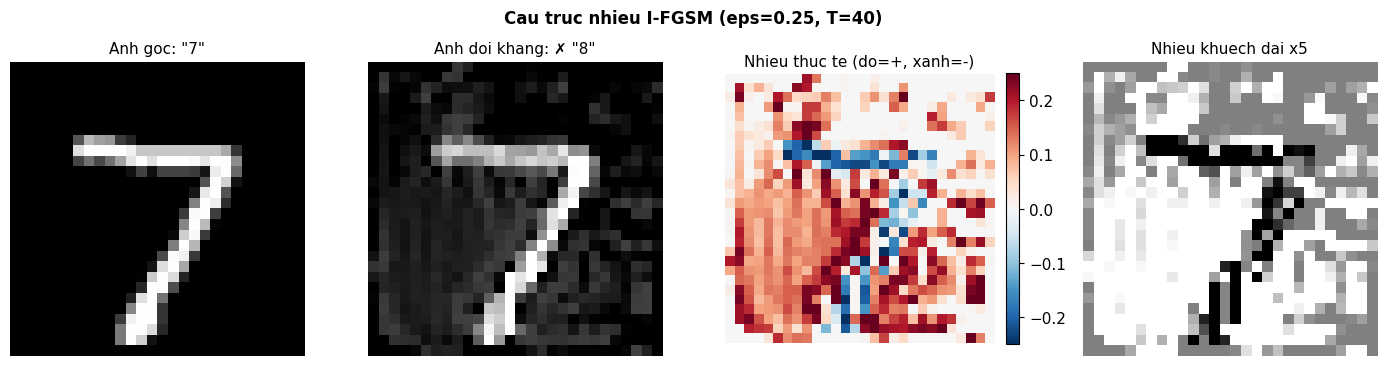

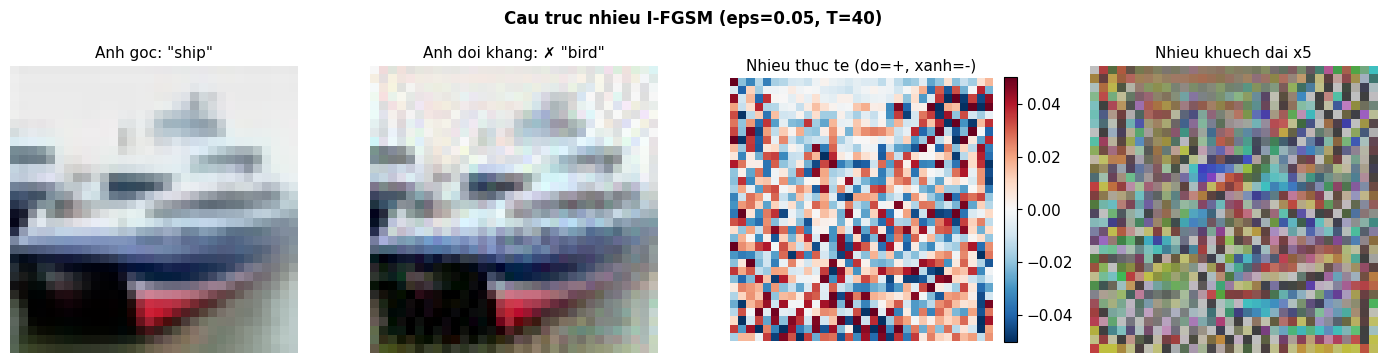

In [14]:
def noise_detail(model, img_t, label, class_names,
                 epsilon=0.2, num_steps=40, cmap=None):
    model.eval()
    lbl_t    = torch.tensor([label])
    attacker = IFGSMAttack(model, epsilon=epsilon, num_steps=num_steps)
    adv_t    = attacker(img_t, lbl_t)
    noise    = (adv_t - img_t).squeeze(0).detach()
    p_adv    = get_probs(model, adv_t)
    pred_adv = p_adv.argmax()

    fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
    fig.suptitle(f'Cau truc nhieu I-FGSM (eps={epsilon}, T={num_steps})',
                 fontsize=12, fontweight='bold')

    axes[0].imshow(to_img(img_t), cmap=cmap, vmin=0, vmax=1)
    axes[0].set_title(f'Anh goc: "{class_names[label]}"', fontsize=11)
    axes[0].axis('off')

    ok  = pred_adv == label
    sym = '\u2713' if ok else '\u2717'
    axes[1].imshow(to_img(adv_t), cmap=cmap, vmin=0, vmax=1)
    axes[1].set_title(f'Anh doi khang: {sym} "{class_names[pred_adv]}"', fontsize=11)
    axes[1].axis('off')

    noise_np = noise.squeeze().numpy() if noise.shape[0]==1 else noise.permute(1,2,0).numpy().mean(-1)
    vmax = max(abs(noise_np.min()), abs(noise_np.max())) + 1e-8
    im = axes[2].imshow(noise_np, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[2].set_title('Nhieu thuc te (do=+, xanh=-)', fontsize=11)
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

    noise_amp = (noise * 5 + 0.5).clamp(0,1)
    axes[3].imshow(to_img(noise_amp.unsqueeze(0)), cmap=cmap, vmin=0, vmax=1)
    axes[3].set_title('Nhieu khuech dai x5', fontsize=11)
    axes[3].axis('off')
    plt.tight_layout(); plt.show()

noise_detail(mnist_model, mnist_imgs[0].unsqueeze(0), mnist_labels[0].item(),
             MNIST_CLS, epsilon=0.25, num_steps=40, cmap='gray')
noise_detail(cifar_model, cifar_imgs[1].unsqueeze(0), cifar_labels[1].item(),
             CIFAR_CLS, epsilon=0.05, num_steps=40)